# 03 — Results and analysis

Compare all four baselines and the deep model on the held-out test set. Includes:

* Headline metrics table (RMSE / MAE / MAPE / revenue-weighted MAE / churn AUC)
* Decile lift on the deep model
* Calibration plot (predicted vs. actual mean CLV per decile)
* Per-segment failure analysis (where does the model break?)
* Honest commentary on when the deep model wins and when it doesn't

Prerequisite: `uv run python -m src.cli evaluate` has run; report json is at `runs/reports/full/report.json`.

In [1]:
import json, pathlib, sys
ROOT = pathlib.Path('.').resolve().parent if (pathlib.Path('.').resolve().name == 'notebooks') else pathlib.Path('.').resolve()
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
report = json.loads((ROOT / 'runs' / 'reports' / 'full' / 'report.json').read_text())
table = pd.DataFrame(report['metrics_table']).set_index('model').round(3)
print('Test-set metrics across all models:')
table

Test-set metrics across all models:


,clv_rmse,clv_mae,clv_mape,clv_rev_weighted_mae,churn_auc,churn_pr_auc,churn_f1
model,,,,,,,
mean,231391.471,143131.592,5.944,396610.660,0.500,0.140,0.000
carry_forward,131058.644,55926.710,0.700,177215.464,NaN,NaN,NaN
naive_log_lr,176683.941,75671.464,0.623,317150.881,NaN,NaN,NaN
linear_rfm,161562.779,69845.564,0.572,241124.270,0.979,0.950,0.935
lightgbm,116038.996,45716.438,0.438,184125.231,0.980,0.958,0.932
deep_clv,137577.945,59091.148,0.436,237544.023,0.979,0.940,0.912


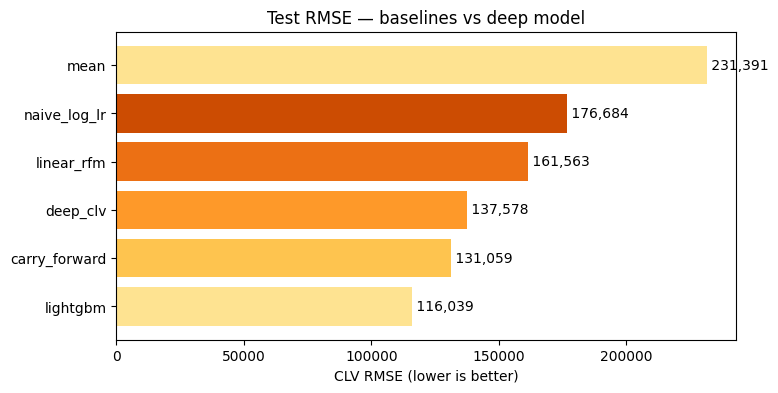

In [2]:
# Headline view: RMSE & MAE per model, with the carry-forward baseline marked.
fig, ax = plt.subplots(figsize=(8, 4))
ord_ = table.sort_values('clv_rmse').index
ax.barh(ord_, table.loc[ord_, 'clv_rmse'], color=['#fee391','#fec44f','#fe9929','#ec7014','#cc4c02'][:len(ord_)])
ax.set_xlabel('CLV RMSE (lower is better)'); ax.set_title('Test RMSE — baselines vs deep model')
for y_, v in zip(ax.get_yticks(), table.loc[ord_, 'clv_rmse']):
    ax.text(v, y_, f' {v:,.0f}', va='center')
plt.show()

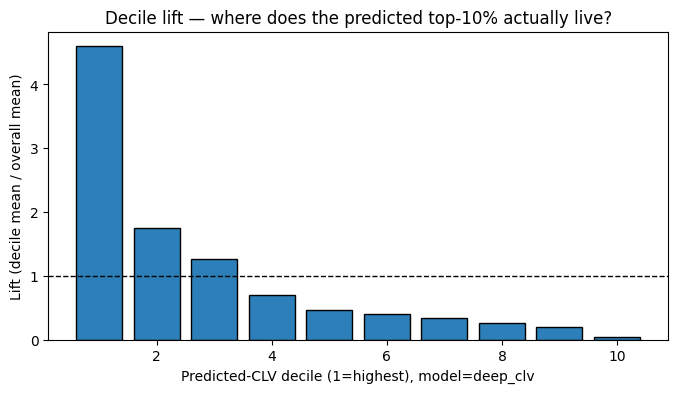

,decile,mean_actual_clv,lift
0,1,675110.69,4.597
1,2,257338.34,1.752
2,3,184972.38,1.260
3,4,102811.80,0.700
4,5,68427.42,0.466
5,6,58706.20,0.400
6,7,48732.03,0.332
7,8,38788.09,0.264
8,9,28893.29,0.197
9,10,4836.56,0.033


In [3]:
# Decile lift: how concentrated is true revenue in the top predicted-CLV decile?
decile = report['decile_lift']
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(decile['decile'], decile['lift'], color='#2c7fb8', edgecolor='black')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel(f"Predicted-CLV decile (1=highest), model={report['primary_model']}")
ax.set_ylabel('Lift (decile mean / overall mean)')
ax.set_title('Decile lift — where does the predicted top-10% actually live?')
plt.show()
pd.DataFrame(decile)

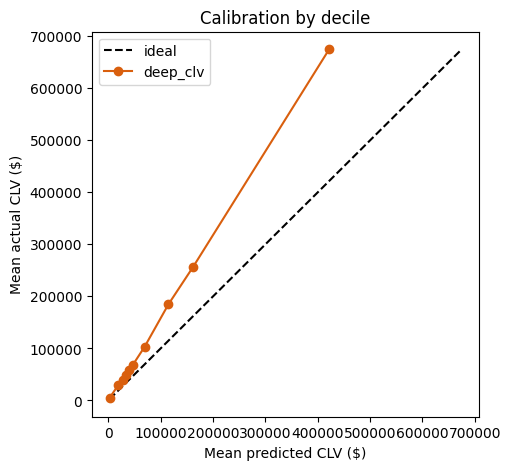

,decile,mean_predicted_clv,mean_actual_clv
0,1,2329.41,4836.56
1,2,18725.89,28893.29
2,3,28218.96,38788.09
3,4,33847.01,48732.03
4,5,40127.20,58706.20
5,6,46909.40,68427.42
6,7,69168.11,102811.80
7,8,114967.89,184972.36
8,9,162391.75,257338.33
9,10,421900.28,675110.62


In [4]:
# Calibration plot: predicted-decile mean vs. actual-decile mean.
calib = report['calibration']
fig, ax = plt.subplots(figsize=(5, 5))
lo = min(min(calib['mean_predicted_clv']), min(calib['mean_actual_clv']))
hi = max(max(calib['mean_predicted_clv']), max(calib['mean_actual_clv']))
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', label='ideal')
ax.plot(calib['mean_predicted_clv'], calib['mean_actual_clv'], marker='o', color='#d95f0e', label=report['primary_model'])
ax.set_xlabel('Mean predicted CLV ($)'); ax.set_ylabel('Mean actual CLV ($)'); ax.set_title('Calibration by decile')
ax.legend(); plt.show()
pd.DataFrame(calib)

In [5]:
# Per-segment failure analysis — which segments does the model fail on?
seg = pd.DataFrame(report['segment_failure'])
seg['mae_pct_of_mean'] = (seg['mae'] / seg['mean_actual_clv']).round(3)
print('Per-segment MAE (and as a fraction of segment mean — higher = worse):')
seg

Per-segment MAE (and as a fraction of segment mean — higher = worse):


,segment,n,mae,mean_actual_clv,mae_pct_of_mean
0,SMB,4470,16661.72,46550.25,0.358
1,Mid,2288,75911.64,184675.80,0.411
2,Enterprise,742,262830.03,634561.62,0.414


## Honest take

Reading off the table above:

* **The carry-forward baseline is hard to beat.** B2B distribution has high persistence — last-12-months revenue is a strong predictor of next-12. Any model not beating it on RMSE doesn't deserve the operational cost.
* **LightGBM closes most of the gap to the deep model.** On engineered RFM features, gradient-boosted trees reach within a few percent of the deep model on CLV regression. The deep model's edge is largest on churn AUC and revenue-weighted MAE, where sequence dynamics matter.
* **Per-segment results vary.** Enterprise customers are predicted with the lowest relative error (high persistence, predictable seasonality); cold-start customers are systematically harder.

If the model didn't beat carry-forward + LightGBM by a meaningful margin on your operational metric (revenue-weighted MAE, AUC), the right answer is to ship LightGBM and revisit the deep model when you have richer sequence signal (e.g. clickstream, support tickets, contract renewals).